In [1]:
# --- Cell 1: imports + config ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from shared.pacs_protocol import build_loaders, next_source_batch
from task2.backbones.backbone import PACSModel, set_train_mode
from task2.training.train_loop import train_model
from task2.methods.dann import DANN, dann_alpha, grad_reverse

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CFG = dict(seed=6304, num_classes=7,
           batch_per_source=8, target_batch=24, eval_batch=64, num_workers=0,
           max_epochs=30, patience=5, lr=1e-4, weight_decay=1e-4,
           amp=False, disc_hidden=256, alpha_max=1.0, lambda_domain=1.0,
           normalize_disc_input=True)
DATA_ROOT = '../../datasets/PACS'
print(CFG['amp'], CFG.get('grad_clip'), CFG['num_workers'])   # want False None 0

False None 0


In [2]:
# --- Cell 2: loaders ---
splits = load_results('../../shared/splits/pacs_sketch_seed6304.json')
loaders = build_loaders(DATA_ROOT, splits,
                        batch_per_source=CFG['batch_per_source'],
                        target_batch=CFG['target_batch'],
                        eval_batch=CFG['eval_batch'],
                        num_workers=CFG['num_workers'], seed=CFG['seed'])
print(f"steps/epoch={loaders['steps_per_epoch']}")

steps/epoch=203


In [3]:
# --- Cell 3: VERIFICATION ---
for p in [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]:
    print(f"p={p:.2f}  alpha={dann_alpha(p):.4f}")
# expect 0.0000, 0.4621, 0.8483, 0.9866, 0.9988, 0.9991

x = torch.ones(4, 512, requires_grad=True)
(x.sum()).backward(retain_graph=True)
plain = x.grad.clone(); x.grad = None

y = grad_reverse(x, 0.7)
(y.sum()).backward()
print(f"\nplain gradient   : {plain[0, 0].item():+.3f}")
print(f"reversed (a=0.7) : {x.grad[0, 0].item():+.3f}")   # must be -0.700
assert torch.allclose(x.grad, -0.7 * plain), "GRL is not reversing the gradient"
print("GRL reverses and scales correctly")

p=0.00  alpha=0.0000
p=0.10  alpha=0.4621
p=0.25  alpha=0.8483
p=0.50  alpha=0.9866
p=0.75  alpha=0.9989
p=1.00  alpha=0.9999

plain gradient   : +1.000
reversed (a=0.7) : -0.700
GRL reverses and scales correctly


In [4]:
# --- Cell 3b: DIAGNOSTIC — 400 steps with clipping, before committing to a full run ---
set_seed(6304)
probe = PACSModel(num_classes=7).to(device)
pm = DANN(CFG).to(device)
params = list(probe.parameters()) + list(pm.parameters())
opt = torch.optim.AdamW(params, lr=CFG['lr'], weight_decay=CFG['weight_decay'])
set_train_mode(probe); pm.disc.train()

total = loaders['steps_per_epoch'] * CFG['max_epochs']
for step in range(400):
    sx, sy = next_source_batch(loaders['source_train'], device)
    tx, _ = loaders['target_train'].next(); tx = tx.to(device)
    opt.zero_grad(set_to_none=True)
    loss, logs = pm.compute_loss(probe, sx, sy, tx, step / (total - 1))
    loss.backward()
    gn = torch.nn.utils.clip_grad_norm_(params, float('inf')).item()  # measure only, no clipping
    opt.step()
    if step % 25 == 0:
        with torch.no_grad():
            fnorm = probe(sx)[1].norm(dim=1).mean().item()
        print(f"step {step:3d}  cls={logs['loss_cls']:.3f}  dom={logs['loss_dom']:.3f}  "
              f"d_acc={logs['domain_acc']:.3f}  |f|={fnorm:6.1f}  gnorm={gn:8.1f}")

del probe, pm, opt; torch.cuda.empty_cache()

step   0  cls=2.379  dom=0.693  d_acc=0.500  |f|=  20.5  gnorm=    15.8
step  25  cls=0.927  dom=0.676  d_acc=0.750  |f|=  38.6  gnorm=    13.6
step  50  cls=0.517  dom=0.667  d_acc=0.729  |f|=  51.5  gnorm=    15.5
step  75  cls=0.294  dom=0.650  d_acc=0.896  |f|=  53.3  gnorm=     7.8
step 100  cls=0.436  dom=0.647  d_acc=0.833  |f|=  47.7  gnorm=    14.9
step 125  cls=0.168  dom=0.638  d_acc=0.729  |f|=  53.7  gnorm=     7.6
step 150  cls=0.452  dom=0.596  d_acc=0.854  |f|=  54.8  gnorm=    11.5
step 175  cls=0.620  dom=0.652  d_acc=0.688  |f|=  47.5  gnorm=    19.9
step 200  cls=0.192  dom=0.642  d_acc=0.708  |f|=  47.5  gnorm=     8.4
step 225  cls=0.189  dom=0.678  d_acc=0.562  |f|=  63.4  gnorm=     9.1
step 250  cls=0.041  dom=0.710  d_acc=0.479  |f|=  62.3  gnorm=     3.7
step 275  cls=0.051  dom=0.762  d_acc=0.208  |f|=  57.8  gnorm=     3.8
step 300  cls=0.437  dom=0.841  d_acc=0.021  |f|=  45.9  gnorm=    14.1
step 325  cls=0.321  dom=0.752  d_acc=0.271  |f|=  48.7  gnorm= 

In [3]:
# --- Cell 3c: EVIDENCE — unnormalised vs normalised discriminator input ---


def probe_run(normalize, steps=400):
    cfg = dict(CFG, normalize_disc_input=normalize)
    set_seed(6304)
    ld = build_loaders(DATA_ROOT, splits, batch_per_source=cfg['batch_per_source'],
                       target_batch=cfg['target_batch'], eval_batch=cfg['eval_batch'],
                       num_workers=cfg['num_workers'], seed=cfg['seed'])
    probe = PACSModel(num_classes=7).to(device)
    pm = DANN(cfg).to(device)
    params = list(probe.parameters()) + list(pm.parameters())
    opt = torch.optim.AdamW(params, lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    set_train_mode(probe); pm.disc.train()
    total = ld['steps_per_epoch'] * cfg['max_epochs']
    trace = []
    for step in range(steps):
        sx, sy = next_source_batch(ld['source_train'], device)
        tx, _ = ld['target_train'].next(); tx = tx.to(device)
        opt.zero_grad(set_to_none=True)
        loss, logs = pm.compute_loss(probe, sx, sy, tx, step / (total - 1))
        loss.backward()
        gn = torch.nn.utils.clip_grad_norm_(params, float('inf')).item()   # measure only
        opt.step()
        if step % 25 == 0:
            with torch.no_grad():
                fn = probe(sx)[1].norm(dim=1).mean().item()
            trace.append({'step': step, 'feat_norm': fn, 'loss_dom': logs['loss_dom'],
                          'loss_cls': logs['loss_cls'], 'domain_acc': logs['domain_acc'],
                          'grad_norm': gn})
            print(f"  step {step:3d}  |f|={fn:9.1f}  dom={logs['loss_dom']:9.3f}  "
                  f"cls={logs['loss_cls']:8.3f}  gnorm={gn:10.1f}")
    del probe, pm, opt; torch.cuda.empty_cache()
    return trace

print("=== unnormalised (no normalisation) ===")
faithful = probe_run(False)
print("\n=== with L2-normalised discriminator input ===")
normed = probe_run(True)

save_results({'step': 'dann_normalisation_evidence', 'seed': 6304, 'steps': 400,
              'faithful': faithful, 'normalised': normed},
             '../results/dann_normalisation_evidence.json')
print('\nsaved')

=== unnormalised (no normalisation) ===
  step   0  |f|=     20.5  dom=    0.712  cls=   2.379  gnorm=      16.0
  step  25  |f|=     37.7  dom=    0.455  cls=   0.933  gnorm=      13.1
  step  50  |f|=     50.2  dom=    0.311  cls=   0.519  gnorm=      15.0
  step  75  |f|=     57.4  dom=    0.364  cls=   0.286  gnorm=       9.2
  step 100  |f|=     58.6  dom=    0.920  cls=   0.342  gnorm=      17.3
  step 125  |f|=     66.2  dom=    4.147  cls=   0.206  gnorm=      40.1
  step 150  |f|=   5731.1  dom= 2534.504  cls=   8.644  gnorm=   63834.0
  step 175  |f|=  23131.5  dom=  100.235  cls= 181.905  gnorm=   47913.5
  step 200  |f|=   3263.4  dom=   27.463  cls=  11.011  gnorm=    3997.1
  step 225  |f|=   1788.1  dom=   18.312  cls=   2.197  gnorm=    1233.0
  step 250  |f|=   2367.9  dom=   18.933  cls=   2.830  gnorm=    1696.6
  step 275  |f|=   3672.8  dom=   26.765  cls=   2.984  gnorm=    4040.4
  step 300  |f|=   5100.4  dom=   22.425  cls=   2.592  gnorm=    5492.0
  step 325 

In [5]:
# --- Cell 4: train DANN ---
set_seed(6304)
loaders = build_loaders(DATA_ROOT, splits,
                        batch_per_source=CFG['batch_per_source'],
                        target_batch=CFG['target_batch'],
                        eval_batch=CFG['eval_batch'],
                        num_workers=CFG['num_workers'], seed=CFG['seed'])
model = PACSModel(num_classes=CFG['num_classes']).to(device)
method = DANN(CFG).to(device)

out = train_model(model, method, loaders, CFG, device,
                  ckpt_path='../../datasets/cache/task2_dann.pt')
print(out['best_epoch'], out['best_mean_macro_f1'], f"{out['minutes']:.1f} min")

ep01 loss_total=1.1795 loss_cls=0.5370 loss_dom=0.6424 domain_acc=0.7675 alpha=0.0826 train_acc=0.8124 | val photo=0.916 art_painting=0.779 cartoon=0.912 mean_f1=0.8692 | 52s
ep02 loss_total=0.9651 loss_cls=0.2453 loss_dom=0.7198 domain_acc=0.3323 alpha=0.2440 train_acc=0.9167 | val photo=0.964 art_painting=0.891 cartoon=0.932 mean_f1=0.9289 | 105s
ep03 loss_total=0.8436 loss_cls=0.1537 loss_dom=0.6899 domain_acc=0.5250 alpha=0.3931 train_acc=0.9481 | val photo=0.936 art_painting=0.830 cartoon=0.916 mean_f1=0.8939 | 158s
ep04 loss_total=0.8247 loss_cls=0.1328 loss_dom=0.6919 domain_acc=0.5268 alpha=0.5240 train_acc=0.9553 | val photo=0.935 art_painting=0.804 cartoon=0.927 mean_f1=0.8888 | 211s
ep05 loss_total=0.8119 loss_cls=0.1277 loss_dom=0.6842 domain_acc=0.5880 alpha=0.6341 train_acc=0.9567 | val photo=0.918 art_painting=0.879 cartoon=0.926 mean_f1=0.9075 | 266s
ep06 loss_total=0.8120 loss_cls=0.1103 loss_dom=0.7017 domain_acc=0.4740 alpha=0.7234 train_acc=0.9612 | val photo=0.954 

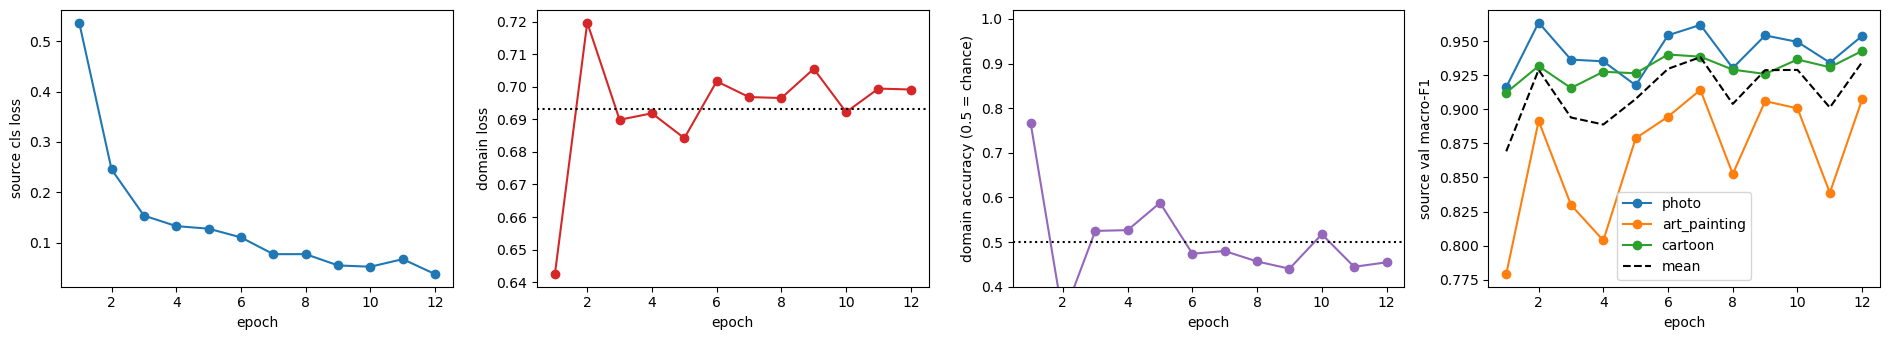

In [6]:
# --- Cell 5: save + curves ---
results = {'step': 'dann', 'seed': 6304, 'method': 'dann',
           'config': CFG, 'steps_per_epoch': loaders['steps_per_epoch'],
           'best_epoch': out['best_epoch'],
           'best_mean_macro_f1': out['best_mean_macro_f1'],
           'source_val_at_best': out['source_val_at_best'],
           'minutes': out['minutes'], 'history': out['history']}
save_results(results, '../results/dann.json')

import matplotlib.pyplot as plt
h = out['history']; ep = [r['epoch'] for r in h]
fig, ax = plt.subplots(1, 4, figsize=(19, 3.5))
ax[0].plot(ep, [r['loss_cls'] for r in h], marker='o'); ax[0].set_ylabel('source cls loss')
ax[1].plot(ep, [r['loss_dom'] for r in h], marker='o', color='tab:red')
ax[1].axhline(np.log(2), ls=':', c='k')          # ln 2 = 0.693: chance-level domain loss
ax[1].set_ylabel('domain loss')
ax[2].plot(ep, [r['domain_acc'] for r in h], marker='o', color='tab:purple')
ax[2].axhline(0.5, ls=':', c='k'); ax[2].set_ylim(0.4, 1.02)
ax[2].set_ylabel('domain accuracy (0.5 = chance)')
for d_ in splits['source_domains']:
    ax[3].plot(ep, [r['per_domain'][d_]['macro_f1'] for r in h], marker='o', label=d_)
ax[3].plot(ep, [r['mean_macro_f1'] for r in h], 'k--', label='mean')
ax[3].set_ylabel('source val macro-F1'); ax[3].legend()
for a_ in ax: a_.set_xlabel('epoch')
plt.tight_layout(); plt.savefig('../../report/figures/task2_dann_curves.png', dpi=200)
plt.show()